# Sweden national resource and emission accounts

**Purpose.** Compute production-based (PBA) and consumption-based (CBA)
accounts for Sweden directly from EXIOBASE 3 — without disaggregation.
Used as a benchmark and validation reference for the Stockholm regional
pre-study.

**Scope.** Three dimensions:
- Dimension 1: Material extraction (kt, 4 Anthesis categories)
- Dimension 2: GHG emissions (kt CO2e, fossil + biogenic)
- Dimension 3: Economic value — total factor inputs (M.EUR)

**GHG row mapping.** Built dynamically from the EXIOBASE `air_emissions/unit.txt`
file so no stressor row is silently skipped due to a name mismatch.

In [1]:
import pymrio
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import logging
import time
import zipfile
import os

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger(__name__)

## Configuration

In [2]:
# Path to EXIOBASE 3 zip file.
EXIOBASE_PATH = Path("C:/EXIOBASE3/IOT_2024_pxp.zip")
if not EXIOBASE_PATH.exists():
    raise FileNotFoundError(f"EXIOBASE file not found: {EXIOBASE_PATH}")

# Path to air_emissions/unit.txt (from the EXIOBASE zip or extracted).
# Adjust if you have extracted the zip to a folder.
UNIT_TXT_PATH = zipfile.ZipFile(EXIOBASE_PATH).open("air_emissions/unit.txt") if EXIOBASE_PATH.suffix == ".zip" else \
    Path("C:/EXIOBASE3/air_emissions/unit.txt")
if not UNIT_TXT_PATH:
    raise FileNotFoundError(f"unit.txt not found in EXIOBASE: {UNIT_TXT_PATH}")

OUTPUT_DIR = Path("./results_sweden")
OUTPUT_DIR.mkdir(exist_ok=True)

SWEDEN_CODE = "SE"
BASE_YEAR   = 2024

## Step 1: Build GHG row mapping from unit.txt

Read the full stressor list from `air_emissions/unit.txt`. Every row is
classified as fossil GHG, biogenic GHG, or non-GHG. GWP factors are applied
according to the confirmed units:
- `kg` rows: multiply by AR5 GWP-100 for the relevant gas
- `kg CO2-eq` rows: GWP = 1 (already in CO2e equivalent)

A validation report is printed so any missing or unclassified rows are visible.

In [3]:
def build_ghg_mapping(unit_txt_path):
    """
    Build GHG row classification from EXIOBASE air_emissions/unit.txt.

    Returns
    -------
    fossil_rows  : dict {stressor_name: gwp_factor}
    biogenic_rows: dict {stressor_name: gwp_factor}
    all_stressors: list of all 420 stressor names (for validation)
    """
    df = pd.read_csv(unit_txt_path, sep='\t')
    df.columns = ['stressor', 'unit']
    stressors = df['stressor'].tolist()
    units     = dict(zip(df['stressor'], df['unit']))

    # AR5 GWP-100 for physical-mass gases (kg)
    GWP_PHYSICAL = {'CO2': 1, 'CH4': 28, 'N2O': 265, 'SF6': 23500}

    # Rules for classifying each stressor.
    # Tuple: (gas_prefix, is_fossil, gwp_override_if_CO2eq)
    FOSSIL_PREFIXES = [
        'CO2 - combustion',
        'CO2 - non combustion - Cement',
        'CO2 - non combustion - Lime',
        'CO2 - waste - fossil',
        'CH4 - combustion',
        'CH4 - non combustion',
        'CH4 - agriculture',
        'CH4 - waste',
        'N2O - combustion',
        'N2O - agriculture',
        'SF6 - air',
        'HFC - air',
        'PFC - air',
    ]
    BIOGENIC_PREFIXES = [
        'CO2_bio',
        'CO2 - agriculture - peat decay',
        'CO2 - waste - biogenic',
        'CH4_bio',
        'N2O_bio',
    ]

    def gwp_for(name, unit_str):
        if unit_str == 'kg CO2-eq':
            return 1  # already CO2e
        for gas, gwp in GWP_PHYSICAL.items():
            if name.startswith(gas):
                return gwp
        return None  # unrecognised gas

    fossil_rows   = {}
    biogenic_rows = {}
    unclassified  = []

    for name in stressors:
        unit_str = units[name]
        gwp = gwp_for(name, unit_str)

        matched_fossil   = any(name.startswith(p) for p in FOSSIL_PREFIXES)
        matched_biogenic = any(name.startswith(p) for p in BIOGENIC_PREFIXES)

        if matched_fossil and gwp is not None:
            fossil_rows[name] = gwp
        elif matched_biogenic and gwp is not None:
            biogenic_rows[name] = gwp
        # else: non-GHG stressor, silently ignored

    return fossil_rows, biogenic_rows, stressors


def validate_ghg_mapping(fossil_rows, biogenic_rows, extension_index):
    """
    Cross-check the mapping against the actual extension index.
    Prints a report of any rows in the mapping that are absent from
    the loaded extension, and any rows present in the extension that
    were not classified.
    """
    ext_rows = set(extension_index)
    mapped   = set(fossil_rows) | set(biogenic_rows)

    missing_from_ext = mapped - ext_rows
    if missing_from_ext:
        print(f'WARNING: {len(missing_from_ext)} mapped row(s) absent from extension:')
        for r in sorted(missing_from_ext):
            print(f'  MISSING: {r}')
    else:
        print(f'Validation OK: all {len(mapped)} mapped rows found in extension.')

    print(f'  Fossil GHG rows   : {len(fossil_rows)}')
    print(f'  Biogenic GHG rows : {len(biogenic_rows)}')
    print(f'  Total extension rows: {len(ext_rows)}')
    print(f'  Non-GHG rows (ignored): {len(ext_rows) - len(mapped)}')


## Step 2: Material category mapping

Map the 62 EXIOBASE material extraction rows to the four Anthesis primary
categories using positional indices (row order is fixed in EXIOBASE 3).

In [4]:
MATERIAL_CATEGORY_MAP = {
    "biomass":  list(range(0, 23)),
    "fossil":   list(range(23, 33)),
    "metals":   list(range(33, 48)),
    "minerals": list(range(48, 62)),
}

all_idx = [i for v in MATERIAL_CATEGORY_MAP.values() for i in v]
assert sorted(all_idx) == list(range(62)), 'Mapping does not cover all 62 rows'
assert len(all_idx) == len(set(all_idx)),  'Overlapping indices'
print('Material category mapping OK: 62 rows -> 4 categories')


def aggregate_material_categories(F_material):
    """Aggregate 62 material rows to 4 Anthesis categories."""
    row_names = F_material.index.tolist()
    result = {}
    for cat, indices in MATERIAL_CATEGORY_MAP.items():
        result[cat] = F_material.loc[[row_names[i] for i in indices]].sum(axis=0)
    return pd.DataFrame(result).T


def aggregate_ghg(F_air, fossil_rows, biogenic_rows):
    """
    Aggregate air emission rows into fossil and biogenic GHG (kt CO2e).

    Source unit : kg  (or kg CO2-eq for HFC/PFC, GWP already = 1).
    Output unit : kt CO2e (divided by 1e6).

    fossil_rows, biogenic_rows : dicts {stressor_name: gwp_factor}
    built by build_ghg_mapping() from unit.txt — no silent row skipping.
    """
    ext_rows = F_air.index.tolist()

    fossil_total = pd.Series(0.0, index=F_air.columns)
    for name, gwp in fossil_rows.items():
        if name in ext_rows:
            fossil_total += F_air.loc[name] * gwp

    bio_total = pd.Series(0.0, index=F_air.columns)
    for name, gwp in biogenic_rows.items():
        if name in ext_rows:
            bio_total += F_air.loc[name] * gwp

    return pd.DataFrame({
        "GHG_fossil_CO2e_kt":   fossil_total / 1e6,
        "GHG_biogenic_CO2e_kt": bio_total    / 1e6,
    }).T


Material category mapping OK: 62 rows -> 4 categories


## Step 3: Load EXIOBASE and compute accounts

Load the full system, compute A, then call `calc_all()` to get L, S,
M, D_pba, and D_cba for all extensions.

**Note on RAM.** Inverting L on the 9800×9800 system requires roughly
730 MiB. Ensure at least 4 GB free RAM before running this cell.

In [5]:
def load_and_calc(path):
    """Load EXIOBASE 3, compute A only (no L), return parsed system."""
    log.info(f'Loading EXIOBASE from {path} ...')
    t0 = time.time()
    exio = pymrio.parse_exiobase3(path=path)
    log.info(f'Parsed in {time.time()-t0:.1f}s. Computing A ...')
    exio.x = pymrio.calc_x(exio.Z, exio.Y)
    exio.A = pymrio.calc_A(exio.Z, exio.x)
    log.info(f'A matrix shape: {exio.A.shape}')
    for ext_name in ['material', 'air_emissions', 'factor_inputs']:
        ext = getattr(exio, ext_name, None)
        if ext is not None and ext.F is not None:
            log.info(f"Extension '{ext_name}': {ext.F.shape[0]} stressors")
        else:
            log.warning(f"Extension '{ext_name}': NOT FOUND")
    return exio


exio = load_and_calc(EXIOBASE_PATH)

# Build GHG mapping from unit.txt
fossil_rows, biogenic_rows, all_stressors = build_ghg_mapping(UNIT_TXT_PATH)

# Validate against the loaded extension
validate_ghg_mapping(fossil_rows, biogenic_rows, exio.air_emissions.F.index)

# Compute all accounts (L, S, M, D_pba, D_cba)
log.info('Running calc_all() — this inverts L on 9800x9800, ~1-5 min ...')
exio.calc_all()
log.info('calc_all() complete.')

2026-04-16 12:36:26,732 INFO Loading EXIOBASE from C:\EXIOBASE3\IOT_2024_pxp.zip ...
2026-04-16 12:36:26,753 INFO Read metadata from C:\EXIOBASE3\IOT_2024_pxp.zip
2026-04-16 12:36:26,755 INFO 20260416 12:36:26 - FILEIO -  Loaded IO system from C:\EXIOBASE3\IOT_2024_pxp.zip - 
2026-04-16 12:36:26,757 INFO Load data from Z.txt
2026-04-16 12:36:44,152 INFO Load data from Y.txt
2026-04-16 12:36:44,397 INFO Load data from x.txt
2026-04-16 12:36:44,413 INFO Load data from unit.txt
2026-04-16 12:36:44,437 INFO Load data from nutrients/F.txt
2026-04-16 12:36:44,581 INFO Load data from nutrients/F_Y.txt
2026-04-16 12:36:44,591 INFO Load data from nutrients/unit.txt
2026-04-16 12:36:44,596 INFO 20260416 12:36:44 - FILEIO -  Added satellite account from nutrients
2026-04-16 12:36:44,605 INFO Load data from material/F.txt
2026-04-16 12:36:44,754 INFO Load data from material/F_Y.txt
2026-04-16 12:36:44,764 INFO Load data from material/unit.txt
2026-04-16 12:36:44,767 INFO 20260416 12:36:44 - FILEIO

Validation OK: all 25 mapped rows found in extension.
  Fossil GHG rows   : 20
  Biogenic GHG rows : 5
  Total extension rows: 420
  Non-GHG rows (ignored): 395


2026-04-16 12:37:01,854 INFO 20260416 12:37:01 - MODIFICATION -  Leontief matrix L calculated
2026-04-16 12:37:01,871 INFO 20260416 12:37:01 - MODIFICATION -  Calculating accounts for extension nutrients
2026-04-16 12:37:12,865 INFO 20260416 12:37:12 - MODIFICATION -  Calculating accounts for extension material
2026-04-16 12:37:23,281 INFO 20260416 12:37:23 - MODIFICATION -  Calculating accounts for extension air_emissions
2026-04-16 12:37:34,809 INFO 20260416 12:37:34 - MODIFICATION -  Calculating accounts for extension factor_inputs
2026-04-16 12:37:45,285 INFO 20260416 12:37:45 - MODIFICATION -  Calculating accounts for extension water
2026-04-16 12:37:56,279 INFO 20260416 12:37:56 - MODIFICATION -  Calculating accounts for extension land
2026-04-16 12:38:07,004 INFO calc_all() complete.


## Step 4: Sweden totals sanity check

Compare against known benchmarks:
- Total domestic material extraction: ~200–300 Mt/year
- Territorial GHG emissions: ~45–50 Mt CO2e/year
- Consumption-based GHG footprint: ~80–100 Mt CO2e/year

In [6]:
se = SWEDEN_CODE

# Materials PBA
mat_F_se  = exio.material.F.loc[:, se]
mat_pba   = aggregate_material_categories(mat_F_se)
print('Sweden material extraction (PBA, kt):')
for cat in mat_pba.index:
    print(f'  {cat:12s}: {mat_pba.loc[cat].sum():>15,.0f}')
print(f'  {"TOTAL":12s}: {mat_pba.sum().sum():>15,.0f}')
print()

# GHG PBA (territorial)
air_F_se  = exio.air_emissions.F.loc[:, se]
ghg_pba   = aggregate_ghg(air_F_se, fossil_rows, biogenic_rows)
print('Sweden GHG emissions (PBA, kt CO2e):')
for cat in ghg_pba.index:
    print(f'  {cat:25s}: {ghg_pba.loc[cat].sum():>12,.1f}')
print(f'  {"Expected territorial":25s}: ~45,000 kt CO2e')
print()

# GHG CBA (consumption-based)
air_D_cba_se = exio.air_emissions.D_cba.loc[:, se]
ghg_cba      = aggregate_ghg(air_D_cba_se, fossil_rows, biogenic_rows)
print('Sweden GHG footprint (CBA, kt CO2e):')
for cat in ghg_cba.index:
    print(f'  {cat:25s}: {ghg_cba.loc[cat].sum():>12,.1f}')
print(f'  {"Expected consumption":25s}: ~80,000-100,000 kt CO2e')
print()

# GHG CBA/PBA ratio check
ratio = ghg_cba.sum().sum() / ghg_pba.sum().sum()
print(f'GHG CBA/PBA ratio: {ratio:.2f}x  (expected 1.5-2.5x for Sweden)')
if ratio > 5:
    print('WARNING: ratio > 5. Check S matrix population in calc_all().')
else:
    print('Ratio within expected range: S matrix is correctly populated.')

Sweden material extraction (PBA, kt):
  biomass     :          64,372
  fossil      :             201
  metals      :          85,280
  minerals    :         128,673
  TOTAL       :         278,525

Sweden GHG emissions (PBA, kt CO2e):
  GHG_fossil_CO2e_kt       :     24,993.3
  GHG_biogenic_CO2e_kt     :        427.9
  Expected territorial     : ~45,000 kt CO2e

Sweden GHG footprint (CBA, kt CO2e):
  GHG_fossil_CO2e_kt       :          0.0
  GHG_biogenic_CO2e_kt     :          0.0
  Expected consumption     : ~80,000-100,000 kt CO2e

GHG CBA/PBA ratio: 0.00x  (expected 1.5-2.5x for Sweden)
Ratio within expected range: S matrix is correctly populated.


## Step 5: Extract Sweden PBA and CBA accounts

In [7]:
def extract_sweden_results(exio, fossil_rows, biogenic_rows):
    """
    Extract Sweden PBA and CBA for three dimensions.
    Returns nested dict with totals and sector-level DataFrames.
    """
    se = SWEDEN_CODE
    results = {}

    # ---- Dimension 1: Materials (kt) ----
    mat = exio.material
    mat_pba_se  = aggregate_material_categories(
        mat.D_pba.loc[:, se].sum(axis=1).to_frame('total'))
    mat_cba_se  = aggregate_material_categories(
        mat.D_cba.loc[:, se].sum(axis=1).to_frame('total'))
    results['material'] = {
        'pba':          mat_pba_se['total'],
        'cba':          mat_cba_se['total'],
        'D_pba_se':     mat.D_pba.loc[:, se],   # (62, 200)
        'D_cba_se':     mat.D_cba.loc[:, se],
        'D_cba_full':   mat.D_cba,
        'unit':         'kt',
    }
    pd.DataFrame({
        'PBA': mat_pba_se['total'],
        'CBA': mat_cba_se['total'],
        'Net': mat_pba_se['total'] - mat_cba_se['total'],
    }).to_csv(OUTPUT_DIR / 'sweden_material_pba_cba.csv')
    log.info('Saved material CSV')

    # ---- Dimension 2: GHG (kt CO2e) ----
    air = exio.air_emissions
    # Check S matrix before using D_cba
    co2_row = 'CO2 - combustion - air'
    s_ok = (air.S is not None and
            air.S.loc[co2_row, se].sum() > 0)
    if not s_ok:
        log.warning('air_emissions.S is zero. Recomputing from F/x ...')
        x_safe   = exio.x.squeeze().replace(0, np.nan)
        S_manual = air.F.div(x_safe, axis=1).fillna(0)
        y_se     = exio.Y.loc[:, se].sum(axis=1)
        M_air    = S_manual @ exio.L
        fp       = M_air.multiply(y_se, axis=1)
        ghg_cba_se = aggregate_ghg(
            fp.loc[:, se].sum(axis=1).to_frame('total'),
            fossil_rows, biogenic_rows)
        D_cba_air_se = fp.loc[:, se]
    else:
        ghg_cba_se   = aggregate_ghg(
            air.D_cba.loc[:, se].sum(axis=1).to_frame('total'),
            fossil_rows, biogenic_rows)
        D_cba_air_se = air.D_cba.loc[:, se]

    ghg_pba_se = aggregate_ghg(
        air.D_pba.loc[:, se].sum(axis=1).to_frame('total'),
        fossil_rows, biogenic_rows)
    ghg_pba_by_sector = aggregate_ghg(
        air.D_pba.loc[:, se], fossil_rows, biogenic_rows)  # (2, 200)

    results['ghg'] = {
        'pba':             ghg_pba_se['total'],
        'cba':             ghg_cba_se['total'],
        'D_pba_by_sector': ghg_pba_by_sector,
        'D_cba_se':        D_cba_air_se,
        'D_cba_full':      air.D_cba,
        'unit':            'kt CO2e',
    }
    pd.DataFrame({
        'PBA': ghg_pba_se['total'],
        'CBA': ghg_cba_se['total'],
        'Net': ghg_pba_se['total'] - ghg_cba_se['total'],
    }).to_csv(OUTPUT_DIR / 'sweden_ghg_pba_cba.csv')
    log.info('Saved GHG CSV')

    # ---- Dimension 3: Factor inputs (M.EUR) ----
    fi = exio.factor_inputs
    results['factor_inputs'] = {
        'pba_total':      fi.D_pba.loc[:, se].sum().sum(),
        'cba_total':      fi.D_cba.loc[:, se].sum().sum(),
        'D_pba_by_sector': fi.D_pba.loc[:, se].sum(axis=0),
        'D_cba_se':       fi.D_cba.loc[:, se],
        'D_cba_full':     fi.D_cba,
        'unit':           'M.EUR',
    }
    log.info('Extracted factor_inputs')

    return results


results = extract_sweden_results(exio, fossil_rows, biogenic_rows)

2026-04-16 12:38:07,110 INFO Saved material CSV
2026-04-16 12:38:07,112 WARNING air_emissions.S is zero. Recomputing from F/x ...
2026-04-16 12:38:07,961 INFO Saved GHG CSV
2026-04-16 12:38:07,966 INFO Extracted factor_inputs


## Step 6: Top sectors by dimension

Rank Sweden's 200 sectors by PBA (territorial production) and CBA
(consumption footprint) for each dimension.

In [8]:
def top_sectors_sweden(results, n=10):
    """Print top N sectors by PBA and CBA for all three dimensions."""
    top = {}
    print('=' * 70)
    print('TOP SECTORS — Sweden national accounts')
    print('=' * 70)

    # ---- Materials ----
    if 'material' in results:
        print('\n--- DIMENSION 1: Material extraction (kt) ---')
        pba_by_sec = aggregate_material_categories(
            results['material']['D_pba_se']).sum(axis=0)
        cba_by_sec = aggregate_material_categories(
            results['material']['D_cba_se']).sum(axis=0)
        pba_top = pba_by_sec.sort_values(ascending=False).head(n)
        cba_top = cba_by_sec.sort_values(ascending=False).head(n)
        print(f"  {'Rank':<5} {'PBA sector':<50} {'kt':>12}")
        for rank, (s, v) in enumerate(pba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        print(f"\n  {'Rank':<5} {'CBA sector':<50} {'kt':>12}")
        for rank, (s, v) in enumerate(cba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        top['material'] = {'pba_top': pba_top, 'cba_top': cba_top}

    # ---- GHG ----
    if 'ghg' in results:
        print('\n--- DIMENSION 2: GHG emissions (kt CO2e) ---')
        pba_by_sec = results['ghg']['D_pba_by_sector'].sum(axis=0)
        cba_by_sec = aggregate_ghg(
            results['ghg']['D_cba_se'], fossil_rows, biogenic_rows).sum(axis=0)
        pba_top = pba_by_sec.sort_values(ascending=False).head(n)
        cba_top = cba_by_sec.sort_values(ascending=False).head(n)
        print(f"  {'Rank':<5} {'PBA sector':<50} {'kt CO2e':>12}")
        for rank, (s, v) in enumerate(pba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        print(f"\n  {'Rank':<5} {'CBA sector':<50} {'kt CO2e':>12}")
        for rank, (s, v) in enumerate(cba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        top['ghg'] = {'pba_top': pba_top, 'cba_top': cba_top}

    # ---- Economic value ----
    if 'factor_inputs' in results:
        print('\n--- DIMENSION 3: Economic value — factor inputs (M.EUR) ---')
        pba_by_sec = results['factor_inputs']['D_pba_by_sector']
        cba_by_sec = results['factor_inputs']['D_cba_se'].sum(axis=0)
        pba_top = pba_by_sec.sort_values(ascending=False).head(n)
        cba_top = cba_by_sec.sort_values(ascending=False).head(n)
        print(f"  {'Rank':<5} {'PBA sector':<50} {'M.EUR':>12}")
        for rank, (s, v) in enumerate(pba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        print(f"\n  {'Rank':<5} {'CBA sector':<50} {'M.EUR':>12}")
        for rank, (s, v) in enumerate(cba_top.items(), 1):
            print(f'  {rank:<5} {str(s)[:50]:<50} {v:>12,.0f}')
        top['factor_inputs'] = {'pba_top': pba_top, 'cba_top': cba_top}

    return top


top = top_sectors_sweden(results, n=10)

TOP SECTORS — Sweden national accounts

--- DIMENSION 1: Material extraction (kt) ---
  Rank  PBA sector                                                   kt
  1     Sand and clay                                           122,575
  2     Iron ores                                                44,253
  3     Products of forestry, logging and related services       42,530
  4     Copper ores and concentrates                             26,749
  5     Precious metal ores and concentrates                     10,460
  6     Cattle                                                    7,217
  7     Stone                                                     6,074
  8     Lead, zinc and tin ores and concentrates                  3,770
  9     Wheat                                                     3,098
  10    Sugar cane, sugar beet                                    2,130

  Rank  CBA sector                                                   kt
  1     Construction work (45)                   

## Step 7: Top source country-sectors for Sweden's consumption footprint

For each dimension, identify the top 15 global (country, sector) pairs
that drive Sweden's consumption-based footprint.

**Method.** S is verified to be non-zero (calc_all() on the original system
populates S correctly). M = S @ L. Footprint = M @ diag(y_sweden).

**Interpretation.** Source = country of production in the global supply
chain. This is directly comparable to the Stockholm analysis.

In [9]:
def top_source_country_sectors_sweden(exio, results, fossil_rows, biogenic_rows, n=15):
    """Top N source (country, sector) pairs for Sweden CBA footprint."""
    se      = SWEDEN_CODE
    x_safe  = exio.x.squeeze().replace(0, np.nan)
    y_se    = exio.Y.loc[:, se].sum(axis=1)

    def label(code):
        return 'Sweden' if code == se else code

    print('=' * 70)
    print('TOP SOURCE COUNTRY-SECTORS — Sweden CBA footprint')
    print('=' * 70)
    cs = {}

    # ---- Materials ----
    if 'material' in results:
        print('\nDIMENSION 1 — Material (kt)')
        S_mat     = exio.material.F.div(x_safe, axis=1).fillna(0)
        M_mat     = S_mat @ exio.L
        fp_mat    = M_mat.multiply(y_se, axis=1)
        fp_mat_tot = aggregate_material_categories(fp_mat).sum(axis=0)
        top_pairs  = fp_mat_tot.sort_values(ascending=False).head(n)
        cs['material'] = {'top_pairs': top_pairs, 'unit': 'kt'}
        print(f"  {'Rank':<5} {'Country':<8} {'Sector':<48} {'kt':>10}")
        for rank, (idx, v) in enumerate(top_pairs.items(), 1):
            print(f'  {rank:<5} {label(idx[0]):<8} {idx[1][:48]:<48} {v:>10,.0f}')

    # ---- GHG ----
    if 'ghg' in results:
        print('\nDIMENSION 2 — GHG (kt CO2e)')
        co2_row = 'CO2 - combustion - air'
        s_ok = (exio.air_emissions.S is not None and
                exio.air_emissions.S.loc[co2_row, se].sum() > 0)
        if s_ok:
            M_air = exio.air_emissions.S @ exio.L
        else:
            log.warning('Recomputing S_air from F/x ...')
            S_air = exio.air_emissions.F.div(x_safe, axis=1).fillna(0)
            M_air = S_air @ exio.L
        fp_ghg     = M_air.multiply(y_se, axis=1)
        fp_ghg_agg = aggregate_ghg(fp_ghg, fossil_rows, biogenic_rows)
        fp_ghg_tot = fp_ghg_agg.sum(axis=0)
        top_pairs  = fp_ghg_tot.sort_values(ascending=False).head(n)
        cs['ghg'] = {'top_pairs': top_pairs, 'unit': 'kt CO2e'}
        print(f"  {'Rank':<5} {'Country':<8} {'Sector':<48} {'kt CO2e':>10}")
        for rank, (idx, v) in enumerate(top_pairs.items(), 1):
            print(f'  {rank:<5} {label(idx[0]):<8} {idx[1][:48]:<48} {v:>10,.0f}')

    # ---- Economic value ----
    if 'factor_inputs' in results:
        print('\nDIMENSION 3 — Economic value (M.EUR)')
        S_fi     = exio.factor_inputs.F.div(x_safe, axis=1).fillna(0)
        M_fi     = S_fi @ exio.L
        fp_fi    = M_fi.multiply(y_se, axis=1)
        fp_fi_tot = fp_fi.sum(axis=0)
        top_pairs = fp_fi_tot.sort_values(ascending=False).head(n)
        cs['factor_inputs'] = {'top_pairs': top_pairs, 'unit': 'M.EUR'}
        print(f"  {'Rank':<5} {'Country':<8} {'Sector':<48} {'M.EUR':>10}")
        for rank, (idx, v) in enumerate(top_pairs.items(), 1):
            print(f'  {rank:<5} {label(idx[0]):<8} {idx[1][:48]:<48} {v:>10,.0f}')

    return cs


cs = top_source_country_sectors_sweden(exio, results, fossil_rows, biogenic_rows, n=15)

TOP SOURCE COUNTRY-SECTORS — Sweden CBA footprint

DIMENSION 1 — Material (kt)


2026-04-16 12:38:08,435 WARNING Recomputing S_air from F/x ...


  Rank  Country  Sector                                                   kt
  1     Sweden   Construction work (45)                               94,230
  2     Sweden   Precious metal ores and concentrates                 23,101
  3     Sweden   Food products nec                                     6,393
  4     Sweden   Health and social work services (85)                  5,637
  5     Sweden   Education services (80)                               5,568
  6     Sweden   Public administration and defence services; comp      5,181
  7     Sweden   Products of meat cattle                               4,943
  8     Sweden   Retail  trade services, except of motor vehicles      3,225
  9     Sweden   Dairy products                                        3,075
  10    Sweden   Computer and related services (72)                    3,056
  11    Sweden   Products of forestry, logging and related servic      2,829
  12    Sweden   Lead, zinc and tin ores and concentrates              2,582

In [10]:
log.info('Saving CSVs ...')
for dim, data in top.items():
    unit = results[dim]['unit']
    data['pba_top'].to_frame(f'PBA_{unit}').to_csv(
        OUTPUT_DIR / f'sweden_top_sectors_PBA_{dim}.csv')
    data['cba_top'].to_frame(f'CBA_{unit}').to_csv(
        OUTPUT_DIR / f'sweden_top_sectors_CBA_{dim}.csv')
for dim, data in cs.items():
    data['top_pairs'].to_frame(f"CBA_{data['unit']}").to_csv(
        OUTPUT_DIR / f'sweden_top_country_sectors_CBA_{dim}.csv')
log.info('All CSVs saved.')
print(f'Output files written to: {OUTPUT_DIR}')

2026-04-16 12:38:09,581 INFO Saving CSVs ...
2026-04-16 12:38:09,617 INFO All CSVs saved.


Output files written to: results_sweden


## Step 8: Visualizations

Six charts mirroring the Stockholm notebook for direct comparison.

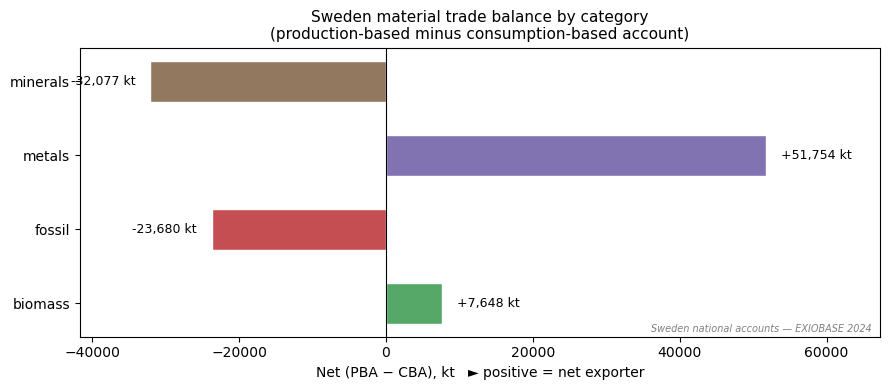

2026-04-16 12:38:10,052 INFO Chart 1 saved


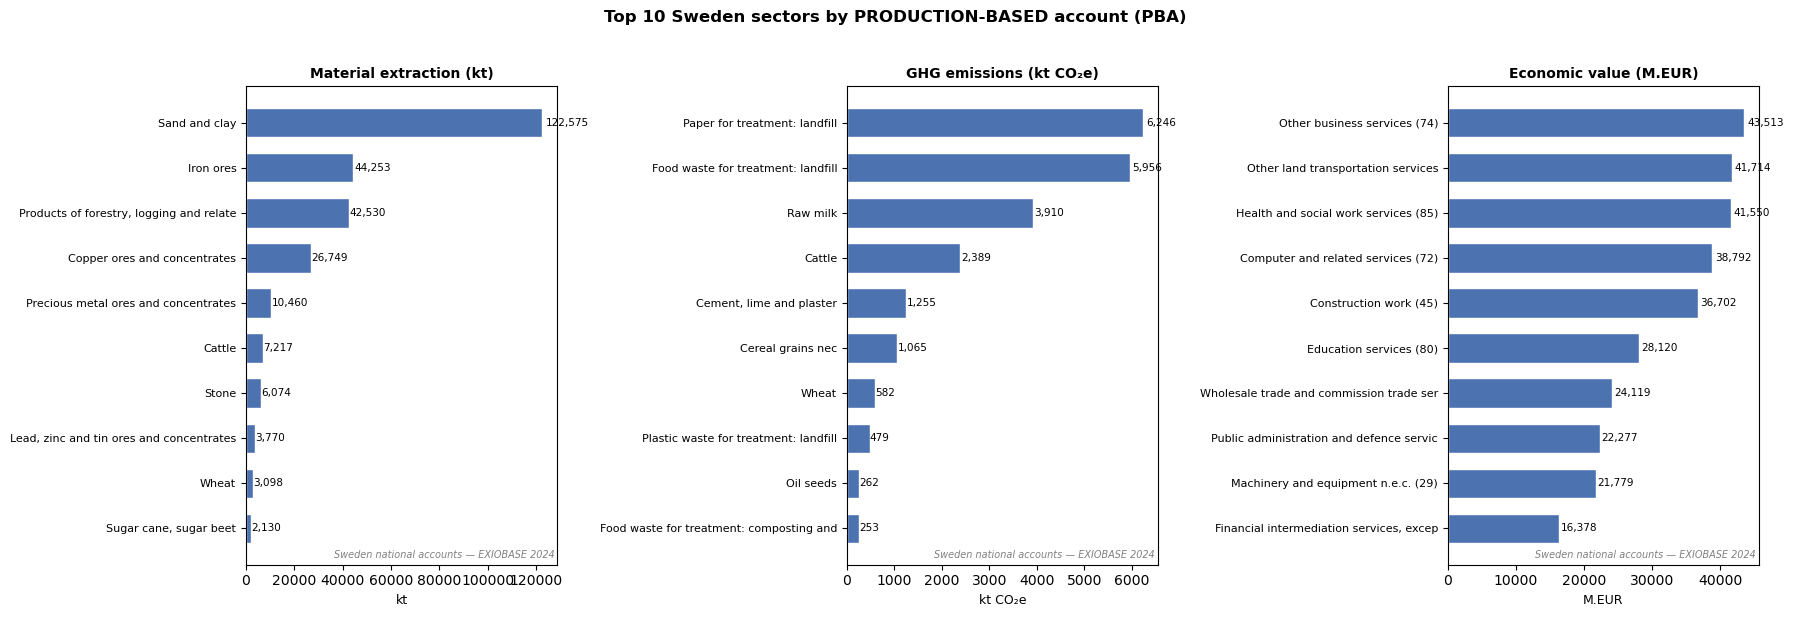

2026-04-16 12:38:10,830 INFO Chart 2 saved


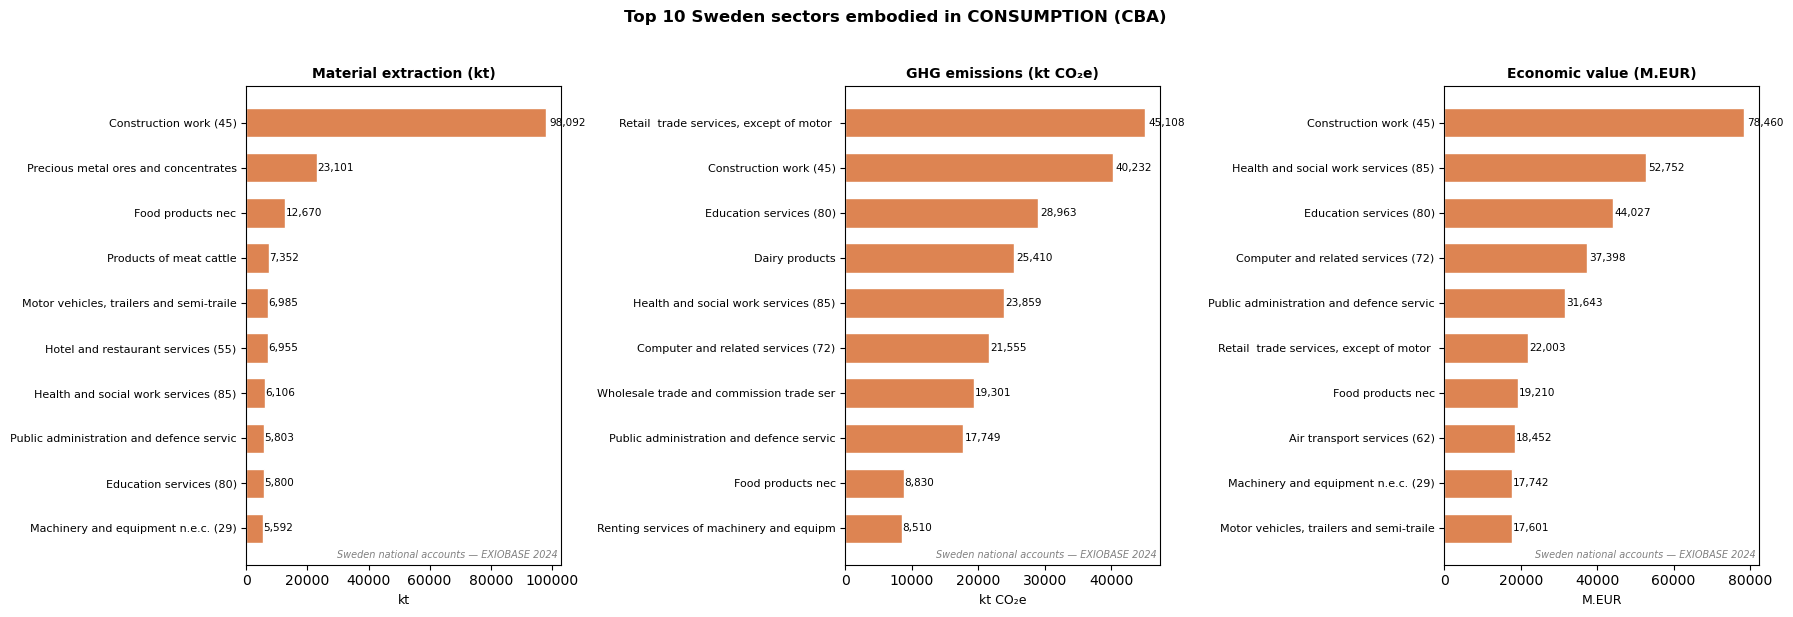

2026-04-16 12:38:11,546 INFO Chart 3 saved


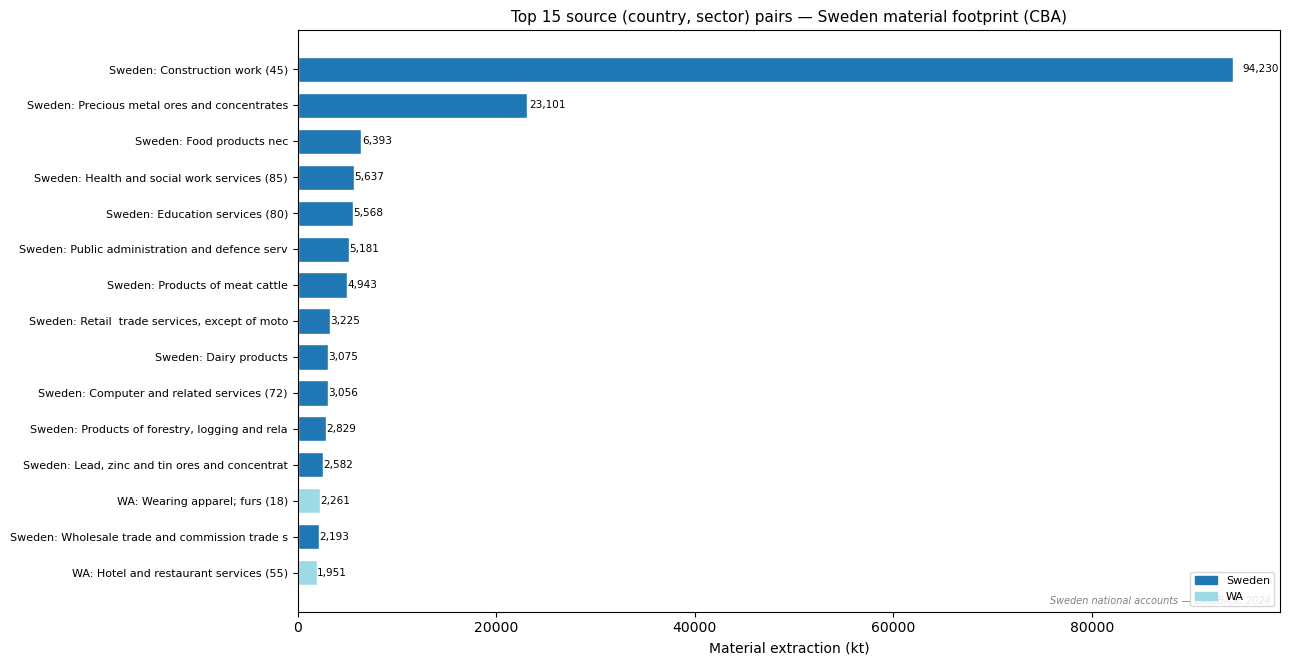

2026-04-16 12:38:12,001 INFO chart4_sweden_source_sectors_material.png saved


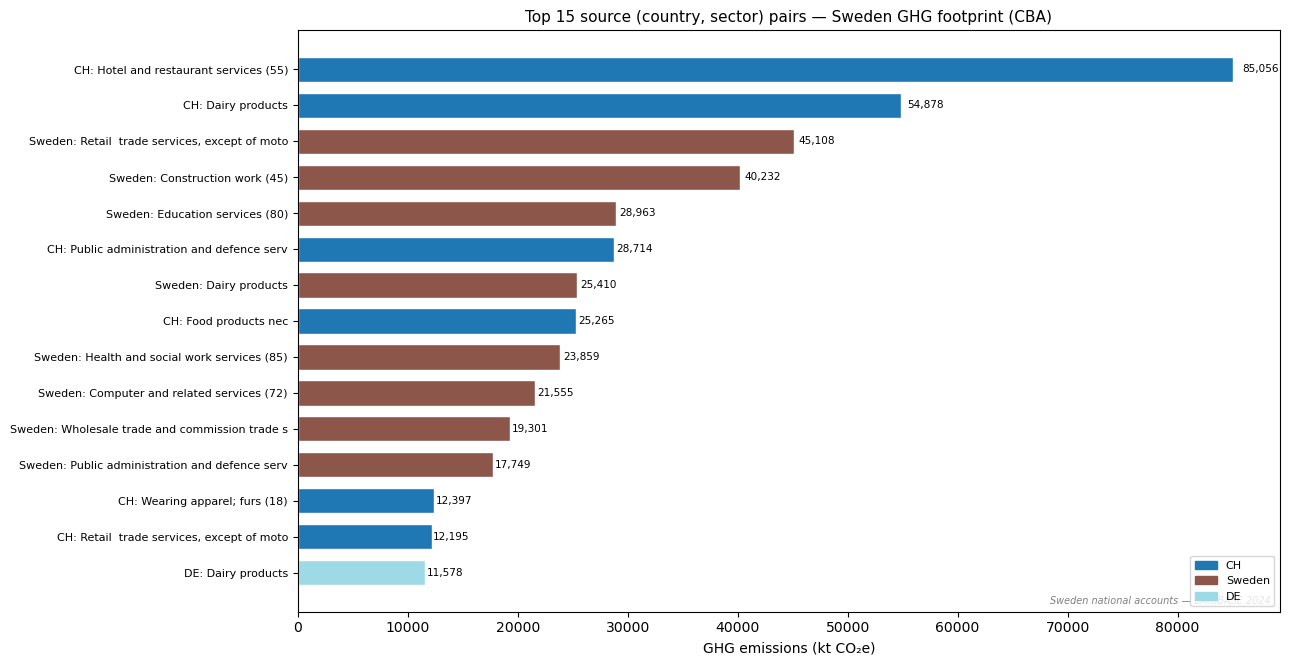

2026-04-16 12:38:12,447 INFO chart5_sweden_source_sectors_ghg.png saved


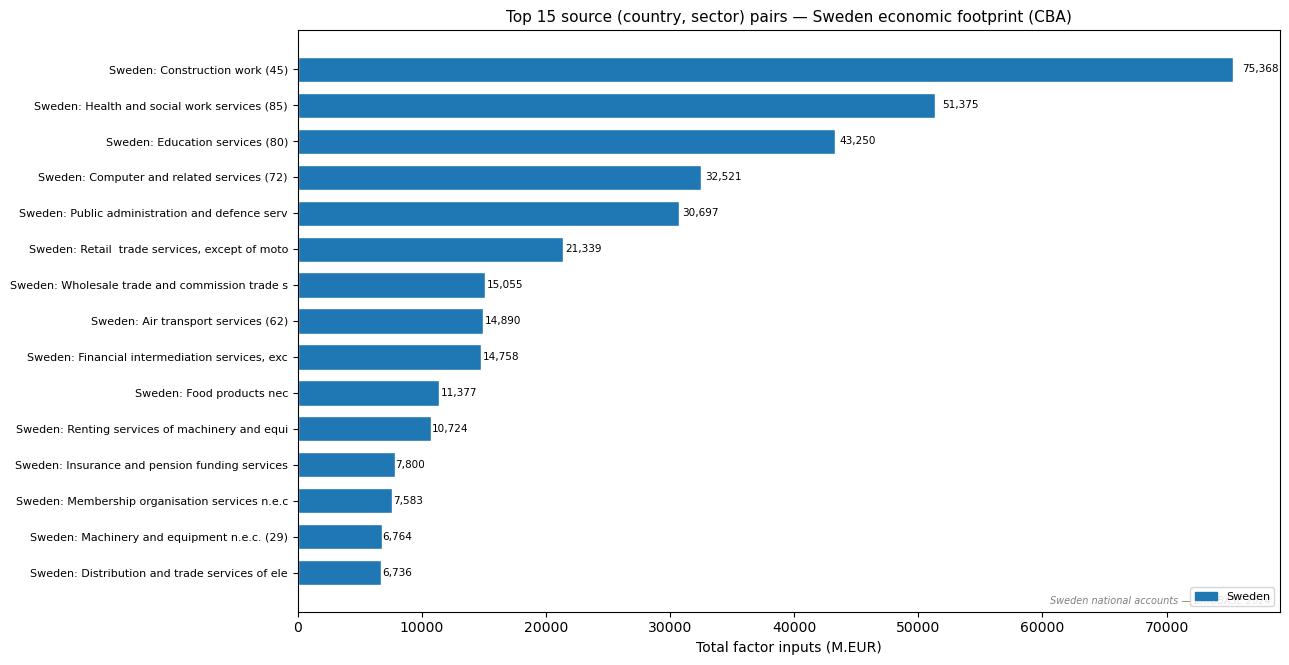

2026-04-16 12:38:12,890 INFO chart6_sweden_source_sectors_economic.png saved



All charts saved to: results_sweden


In [11]:
PROXY_NOTE = 'Sweden national accounts — EXIOBASE 2024'
C_PBA = '#4C72B0'
C_CBA = '#DD8452'
CAT_COLORS = {
    'biomass':  '#55A868',
    'fossil':   '#C44E52',
    'metals':   '#8172B2',
    'minerals': '#937860',
}

def add_note(ax):
    ax.text(0.99, 0.01, PROXY_NOTE, transform=ax.transAxes,
            fontsize=7, color='grey', ha='right', va='bottom', style='italic')

def fmt_pair(idx):
    country, sector = idx
    label = 'Sweden' if country == SWEDEN_CODE else country
    return f'{label}: {sector[:38]}'

def country_sector_chart(top_pairs, xlabel, title, filename):
    labels = [fmt_pair(idx) for idx in top_pairs.index]
    vals   = top_pairs.values
    unique_c = list(dict.fromkeys(idx[0] for idx in top_pairs.index))
    cmap   = matplotlib.colormaps.get_cmap('tab20').resampled(max(len(unique_c), 1))
    c_map  = {c: cmap(i) for i, c in enumerate(unique_c)}
    colors = [c_map[idx[0]] for idx in top_pairs.index]
    fig, ax = plt.subplots(figsize=(13, max(6, len(labels) * 0.45)))
    y = np.arange(len(labels))
    ax.barh(y, vals, color=colors, edgecolor='white', height=0.7)
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8); ax.invert_yaxis()
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    patches = [mpatches.Patch(color=c_map[c],
               label='Sweden' if c == SWEDEN_CODE else c) for c in unique_c]
    ax.legend(handles=patches, loc='lower right', fontsize=8)
    for i, v in enumerate(vals):
        ax.text(v * 1.01, i, f'{v:,.0f}', va='center', fontsize=7.5)
    add_note(ax)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    log.info(f'{filename} saved')


# Chart 1: Net material trade balance
fig, ax = plt.subplots(figsize=(9, 4))
cats = results['material']['pba'].index.tolist()
net  = (results['material']['pba'] - results['material']['cba']).values
cols = [CAT_COLORS.get(c, '#999') for c in cats]
bars = ax.barh(cats, net, color=cols, edgecolor='white', height=0.55)
ax.axvline(0, color='black', linewidth=0.8)
rng = max(abs(net)) * 0.04
for bar, val in zip(bars, net):
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + rng * (1 if val >= 0 else -1),
            bar.get_y() + bar.get_height() / 2,
            f'{val:+,.0f} kt', va='center', ha=ha, fontsize=9)
ax.set_xlabel('Net (PBA − CBA), kt   ► positive = net exporter', fontsize=10)
ax.set_title('Sweden material trade balance by category\n'
             '(production-based minus consumption-based account)', fontsize=11)
ax.set_xlim(min(net)*1.3, max(net)*1.3)
add_note(ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart1_sweden_material_balance.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('Chart 1 saved')


# Chart 2: Top 10 PBA sectors — three dimensions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
panels = [
    ('Material extraction (kt)',   top['material']['pba_top']),
    ('GHG emissions (kt CO₂e)', top['ghg']['pba_top']),
    ('Economic value (M.EUR)',     top['factor_inputs']['pba_top']),
]
for ax, (title, data) in zip(axes, panels):
    secs = [str(s)[:40] for s in data.index]
    vals = data.values
    y = np.arange(len(secs))
    ax.barh(y, vals, color=C_PBA, edgecolor='white', height=0.65)
    ax.set_yticks(y); ax.set_yticklabels(secs, fontsize=8); ax.invert_yaxis()
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(title.split('(')[1].rstrip(')'), fontsize=9)
    for i, v in enumerate(vals):
        ax.text(v*1.01, i, f'{v:,.0f}', va='center', fontsize=7.5)
    add_note(ax)
fig.suptitle('Top 10 Sweden sectors by PRODUCTION-BASED account (PBA)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart2_sweden_top_sectors_PBA.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('Chart 2 saved')


# Chart 3: Top 10 CBA sectors — three dimensions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
panels_cba = [
    ('Material extraction (kt)',   top['material']['cba_top']),
    ('GHG emissions (kt CO₂e)', top['ghg']['cba_top']),
    ('Economic value (M.EUR)',     top['factor_inputs']['cba_top']),
]
for ax, (title, data) in zip(axes, panels_cba):
    secs = [str(s)[:40] for s in data.index]
    vals = data.values
    y = np.arange(len(secs))
    ax.barh(y, vals, color=C_CBA, edgecolor='white', height=0.65)
    ax.set_yticks(y); ax.set_yticklabels(secs, fontsize=8); ax.invert_yaxis()
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(title.split('(')[1].rstrip(')'), fontsize=9)
    for i, v in enumerate(vals):
        ax.text(v*1.01, i, f'{v:,.0f}', va='center', fontsize=7.5)
    add_note(ax)
fig.suptitle('Top 10 Sweden sectors embodied in CONSUMPTION (CBA)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart3_sweden_top_sectors_CBA.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('Chart 3 saved')


# Charts 4-6: Top source country-sector pairs
if 'material' in cs:
    country_sector_chart(
        cs['material']['top_pairs'],
        'Material extraction (kt)',
        'Top 15 source (country, sector) pairs — Sweden material footprint (CBA)',
        'chart4_sweden_source_sectors_material.png')

if 'ghg' in cs:
    country_sector_chart(
        cs['ghg']['top_pairs'],
        'GHG emissions (kt CO₂e)',
        'Top 15 source (country, sector) pairs — Sweden GHG footprint (CBA)',
        'chart5_sweden_source_sectors_ghg.png')

if 'factor_inputs' in cs:
    country_sector_chart(
        cs['factor_inputs']['top_pairs'],
        'Total factor inputs (M.EUR)',
        'Top 15 source (country, sector) pairs — Sweden economic footprint (CBA)',
        'chart6_sweden_source_sectors_economic.png')

print(f'\nAll charts saved to: {OUTPUT_DIR}')

## Summary

In [12]:
print('=' * 70)
print('SUMMARY — Sweden national resource and emission accounts')
print('=' * 70)
print(f'Base year : {BASE_YEAR}')
print()

print('--- DIMENSION 1: Material extraction (kt) ---')
print(f"  {'Category':>12}  {'PBA':>12}  {'CBA':>12}  {'Net':>12}  Direction")
for cat in results['material']['pba'].index:
    pba = results['material']['pba'][cat]
    cba = results['material']['cba'][cat]
    net = pba - cba
    print(f"  {cat:>12}  {pba:>12,.0f}  {cba:>12,.0f}  {net:>12,.0f}  "
          f"{'net exporter' if net > 0 else 'NET IMPORTER'}")
print()

print('--- DIMENSION 2: GHG emissions (kt CO2e) ---')
print(f"  {'Category':>25}  {'PBA':>12}  {'CBA':>12}  {'Net':>12}  Direction")
for cat in results['ghg']['pba'].index:
    pba = results['ghg']['pba'][cat]
    cba = results['ghg']['cba'][cat]
    net = pba - cba
    print(f"  {cat:>25}  {pba:>12,.0f}  {cba:>12,.0f}  {net:>12,.0f}  "
          f"{'net exporter' if net > 0 else 'NET IMPORTER'}")
print()

print('--- DIMENSION 3: Economic value — factor inputs (M.EUR) ---')
pba_fi = results['factor_inputs']['pba_total']
cba_fi = results['factor_inputs']['cba_total']
print(f"  PBA (Sweden production value) : {pba_fi:>14,.0f} M.EUR")
print(f"  CBA (Sweden consumption value): {cba_fi:>14,.0f} M.EUR")
print(f"  Net (PBA - CBA)               : {pba_fi - cba_fi:>14,.0f} M.EUR")

SUMMARY — Sweden national resource and emission accounts
Base year : 2024

--- DIMENSION 1: Material extraction (kt) ---
      Category           PBA           CBA           Net  Direction
       biomass        64,372        56,724         7,648  net exporter
        fossil           201        23,881       -23,680  NET IMPORTER
        metals        85,280        33,525        51,754  net exporter
      minerals       128,673       160,750       -32,077  NET IMPORTER

--- DIMENSION 2: GHG emissions (kt CO2e) ---
                   Category           PBA           CBA           Net  Direction
         GHG_fossil_CO2e_kt        24,927       313,934      -289,007  NET IMPORTER
       GHG_biogenic_CO2e_kt           428         3,269        -2,841  NET IMPORTER

--- DIMENSION 3: Economic value — factor inputs (M.EUR) ---
  PBA (Sweden production value) :        561,537 M.EUR
  CBA (Sweden consumption value):        537,934 M.EUR
  Net (PBA - CBA)               :         23,603 M.EUR
